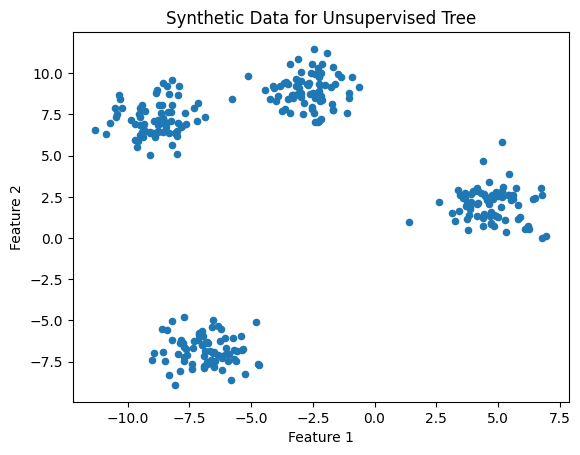

In [1]:
from sklearn.datasets import make_blobs 
import matplotlib.pyplot as plt 
# Generate synthetic data with clear clusters 
X, _ = make_blobs(n_samples=300, centers=4, n_features=2, random_state=42) 
plt.scatter(X[:, 0], X[:, 1], s=20) 
plt.title("Synthetic Data for Unsupervised Tree") 
plt.xlabel("Feature 1") 
plt.ylabel("Feature 2") 
plt.show() 

In [2]:
import numpy as np 
from sklearn.metrics import silhouette_score 
 
def best_split(X, min_leaf_size=5): 
    best_score = -1 
    best_feature, best_threshold = None, None 
    n_samples, n_features = X.shape 
     
    for f in range(n_features): 
        thresholds = np.unique(X[:, f]) 
        for t in thresholds: 
            left_mask = X[:, f] <= t 
            right_mask = ~left_mask 
            if left_mask.sum() < min_leaf_size or right_mask.sum() < min_leaf_size: 
                continue 
             
            labels = np.zeros(n_samples) 
            labels[right_mask] = 1 
            score = silhouette_score(X, labels) 
             
            if score > best_score: 
                best_score = score 
                best_feature, best_threshold = f, t 
     
    return best_feature, best_threshold, best_score 

In [3]:
feature, threshold, score = best_split(X) 
print(f"Best split on feature {feature}, threshold {threshold:.3f}, silhouette score = 
{score:.3f}") 
 
plt.scatter(X[:, 0], X[:, 1], c=(X[:, feature] > threshold), cmap='coolwarm', s=20) 
if feature == 0: 
    plt.axvline(threshold, color='k', linestyle='--') 
else: 
    plt.axhline(threshold, color='k', linestyle='--') 
plt.title(f"Best Split (Feature {feature}, Threshold {threshold:.2f})") 
plt.show() 

SyntaxError: unterminated string literal (detected at line 2) (214728256.py, line 2)

In [4]:
class UnsupervisedTree: 
    def __init__(self, min_leaf_size=10, min_gain=0.01, depth=0, max_depth=3): 
        self.min_leaf_size = min_leaf_size 
        self.min_gain = min_gain 
        self.depth = depth 
        self.max_depth = max_depth 
        self.is_leaf = False 
 
    def fit(self, X): 
        if self.depth >= self.max_depth: 
            self.is_leaf = True 
            return 
         
        feature, threshold, score = best_split(X, self.min_leaf_size) 
        if feature is None or score < self.min_gain: 
            self.is_leaf = True 
            return 
         
        self.feature, self.threshold, self.score = feature, threshold, score 
        left_mask = X[:, feature] <= threshold 
        right_mask = ~left_mask 
 
        self.left = UnsupervisedTree(self.min_leaf_size, self.min_gain, self.depth+1, 
self.max_depth) 
        self.right = UnsupervisedTree(self.min_leaf_size, self.min_gain, self.depth+1, 
self.max_depth) 
         
        self.left.fit(X[left_mask]) 
        self.right.fit(X[right_mask]) 
         
    def predict(self, X): 
        if self.is_leaf: 
            return np.zeros(X.shape[0]) + self.depth 
        mask = X[:, self.feature] > self.threshold 
        left_labels = self.left.predict(X[~mask]) 
        right_labels = self.right.predict(X[mask]) + 1 
        labels = np.zeros(X.shape[0]) 
labels[~mask] = left_labels 
labels[mask] = right_labels 
return labels

NameError: name 'left_labels' is not defined

In [5]:
tree = UnsupervisedTree(max_depth=3, min_leaf_size=10) 
tree.fit(X) 
labels = tree.predict(X) 
plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis', s=20) 
plt.title("Tree-Based Clustering (Silhouette Splitting)") 
plt.show()

TypeError: unsupported operand type(s) for +: 'NoneType' and 'int'